# 🔬 3강. 타겟 단백질의 3D 구조 분석
## CDK1 — 간암 예후 마커에서 치료 표적으로

---

## 2강 복습 & 오늘의 연결고리

> 2강에서 우리는 **CDK1** 이 예후 나쁜 간암 환자에서 높게 발현된다는 것을 발견했습니다.  
> 그렇다면 **"CDK1을 약으로 억제할 수 있을까?"**  
> 그 답을 찾으려면 단백질의 **3D 구조**를 이해해야 합니다.

```
2강: CDK1 발현↑ → 예후 나쁨 (단백체 데이터)
                    ↓
3강: CDK1 3D 구조 → 약물 결합 부위 → 억제제 설계
```

## 오늘 배울 것

| 단계 | 내용 |
|------|------|
| 1 | PDB에서 CDK1 구조 데이터 받기 |
| 2 | PDB 파일 구조 이해 & 파싱 |
| 3 | 아미노산 배치 & 2D 구조 분석 |
| 4 | py3Dmol로 3D 구조 시각화 |
| 5 | 활성부위(ATP binding site) 분석 |

In [1]:
# ======================================
# 📦 라이브러리 설치 및 불러오기
# ======================================

import subprocess, sys

# py3Dmol 설치 (3D 시각화)
subprocess.run([sys.executable, '-m', 'pip', 'install', 'py3Dmol', '-q'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import os
import py3Dmol
from collections import defaultdict

# 한글 폰트
import matplotlib.font_manager as fm
NANUM_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(NANUM_PATH):
    fm.fontManager.addfont(NANUM_PATH)
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('✅ 준비 완료!')
print(f'   py3Dmol 버전: {py3Dmol.__version__}')


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


✅ 준비 완료!
   py3Dmol 버전: 2.5.5


---
## 🗄️ 3-1. PDB란? CDK1 구조 데이터 받기

### Protein Data Bank (PDB)

전 세계 연구자들이 X선 결정학, 냉동전자현미경(cryo-EM) 등으로  
밝혀낸 **단백질 3D 구조를 무료로 제공하는 데이터베이스**입니다.

- 주소: https://www.rcsb.org
- 현재 약 **22만 개** 이상의 구조 보유
- 각 구조는 **4자리 PDB ID** 로 구분 (예: `6GU6`)

### CDK1의 PDB 구조

| PDB ID | 설명 |
|--------|------|
| `6GU6` | CDK1 + 억제제(1QK) 복합체 |
| `6GU6` | CDK1 + 억제제 결합 구조 |

> 오늘은 `6GU6` 을 사용합니다.

In [2]:
# ======================================
# 🗄️ PDB에서 CDK1 구조 다운로드
# ======================================

PDB_ID = '6GU6'

# RCSB PDB API로 다운로드
url = f'https://files.rcsb.org/download/{PDB_ID}.pdb'
print(f'다운로드 중: {url}')

response = requests.get(url)
if response.status_code == 200:
    pdb_text = response.text
    with open(f'{PDB_ID}.pdb', 'w') as f:
        f.write(pdb_text)
    print(f'✅ {PDB_ID}.pdb 다운로드 완료!')
    print(f'   파일 크기: {len(pdb_text):,} 문자')
    print(f'   총 줄 수: {pdb_text.count(chr(10)):,} 줄')
else:
    print(f'❌ 다운로드 실패: {response.status_code}')

# 파일 앞부분 미리보기
print()
print('=== PDB 파일 첫 20줄 ===' )
for i, line in enumerate(pdb_text.split('\n')[:20]):
    print(f'{i+1:3d}: {line}')

다운로드 중: https://files.rcsb.org/download/6GU6.pdb
✅ 6GU6.pdb 다운로드 완료!
   파일 크기: 288,036 문자
   총 줄 수: 3,556 줄

=== PDB 파일 첫 20줄 ===
  1: HEADER    CELL CYCLE                              19-JUN-18   6GU6              
  2: TITLE     CDK1/CKS2 IN COMPLEX WITH DINACICLIB                                  
  3: COMPND    MOL_ID: 1;                                                            
  4: COMPND   2 MOLECULE: CYCLIN-DEPENDENT KINASE 1;                                 
  5: COMPND   3 CHAIN: A;                                                            
  6: COMPND   4 SYNONYM: CDK1,CELL DIVISION CONTROL PROTEIN 2 HOMOLOG,CELL DIVISION  
  7: COMPND   5 PROTEIN KINASE 1,P34 PROTEIN KINASE;                                 
  8: COMPND   6 EC: 2.7.11.22,2.7.11.23;                                             
  9: COMPND   7 ENGINEERED: YES;                                                     
 10: COMPND   8 MOL_ID: 2;                                                           
 11: COMPN

---
## 📄 3-2. PDB 파일 구조 이해

PDB 파일은 텍스트 형식입니다. 각 줄의 첫 6자리가 **레코드 타입**을 나타냅니다.

```
HEADER  단백질 이름, 날짜, PDB ID
REMARK  실험 방법, 해상도 등 메타정보
SEQRES  아미노산 서열
HETATM  리간드/약물/물 분자 원자 좌표
ATOM    단백질 원자 좌표  ← 가장 중요!
```

### ATOM 레코드 형식
```
ATOM   1234  CA  ALA A  45      12.345  23.456  34.567  1.00 15.23  C
       번호  원자 잔기 체인 번호     X       Y       Z     점유율 B-factor 원소
```

In [3]:
# ======================================
# 📄 PDB 파일 파싱
# ======================================

def parse_pdb(pdb_text):
    """
    PDB 파일을 파싱해서 원자 정보를 DataFrame으로 반환합니다.
    ATOM: 단백질 원자
    HETATM: 리간드/약물 원자
    """
    atoms = []
    for line in pdb_text.split('\n'):
        if line.startswith('ATOM') or line.startswith('HETATM'):
            try:
                atoms.append({
                    'record':    line[0:6].strip(),
                    'atom_num':  int(line[6:11]),
                    'atom_name': line[12:16].strip(),
                    'res_name':  line[17:20].strip(),
                    'chain':     line[21].strip(),
                    'res_num':   int(line[22:26]),
                    'x':         float(line[30:38]),
                    'y':         float(line[38:46]),
                    'z':         float(line[46:54]),
                    'b_factor':  float(line[60:66]) if len(line) > 66 else 0.0,
                    'element':   line[76:78].strip() if len(line) > 76 else ''
                })
            except:
                continue
    return pd.DataFrame(atoms)


df_atoms = parse_pdb(pdb_text)

print(f'전체 원자 수: {len(df_atoms):,}개')
print(f'체인 종류: {df_atoms["chain"].unique().tolist()}')
print()

# 체인별 정보
print('체인별 구성:')
for chain in sorted(df_atoms['chain'].unique()):
    chain_df   = df_atoms[df_atoms['chain'] == chain]
    n_residues = chain_df[chain_df['record']=='ATOM']['res_num'].nunique()
    n_atoms    = len(chain_df[chain_df['record']=='ATOM'])
    ligands    = chain_df[chain_df['record']=='HETATM']['res_name'].unique().tolist()
    print(f'  Chain {chain}: {n_residues}개 잔기, {n_atoms}개 원자', end='')
    if ligands:
        print(f', 리간드: {ligands}')
    else:
        print()

print()
print('ATOM 레코드 샘플 (처음 5개):')
print(df_atoms[df_atoms['record']=='ATOM'].head()[['atom_name','res_name','chain','res_num','x','y','z']].to_string(index=False))

전체 원자 수: 3,058개
체인 종류: ['A', 'B']

체인별 구성:
  Chain A: 288개 잔기, 2323개 원자, 리간드: ['1QK', 'HOH']
  Chain B: 70개 잔기, 620개 원자, 리간드: ['HOH']

ATOM 레코드 샘플 (처음 5개):
atom_name res_name chain  res_num      x      y       z
        N      MET     A        1 14.467 16.694 -18.439
       CA      MET     A        1 13.501 17.597 -19.079
        C      MET     A        1 14.279 18.608 -19.905
        O      MET     A        1 15.307 19.154 -19.469
       CB      MET     A        1 12.697 18.318 -18.026


CDK1 (Chain A) 아미노산 수: 288개
서열 (처음 60개):
MEDYTKIEKIGEGTYGVVYKGRHKTTGQVVAMKKIRLESEEEGVPSTAIREISLLKELRH



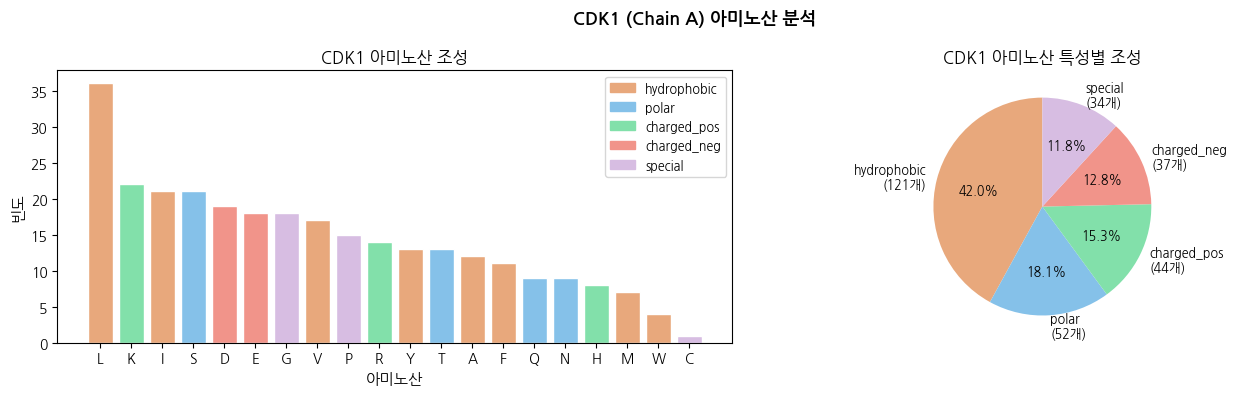

In [5]:
# ======================================
# 🧬 아미노산 서열 추출 & 조성 분석
# ======================================

# 3글자 → 1글자 아미노산 코드 변환
AA_3TO1 = {
    'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C',
    'GLN':'Q','GLU':'E','GLY':'G','HIS':'H','ILE':'I',
    'LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P',
    'SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V'
}

# CDK1 체인 A 서열 추출
cdk1_chain = df_atoms[
    (df_atoms['chain'] == 'A') &
    (df_atoms['record'] == 'ATOM') &
    (df_atoms['atom_name'] == 'CA')  # Cα 원자만 (잔기당 1개)
].copy()

sequence_1letter = ''.join([
    AA_3TO1.get(row['res_name'], 'X')
    for _, row in cdk1_chain.iterrows()
])

print(f'CDK1 (Chain A) 아미노산 수: {len(sequence_1letter)}개')
print(f'서열 (처음 60개):')
print(sequence_1letter[:60])
print()

# 아미노산 조성 분석
aa_counts = pd.Series(list(sequence_1letter)).value_counts()

# 아미노산 특성별 색상
aa_properties = {
    'hydrophobic': list('AVILMFYW'),
    'polar':       list('STNQ'),
    'charged_pos': list('RKH'),
    'charged_neg': list('DE'),
    'special':     list('CGP'),
}
prop_colors = {
    'hydrophobic': '#E8A87C',
    'polar':       '#85C1E9',
    'charged_pos': '#82E0AA',
    'charged_neg': '#F1948A',
    'special':     '#D7BDE2',
}

def get_aa_color(aa):
    for prop, aas in aa_properties.items():
        if aa in aas:
            return prop_colors[prop]
    return 'lightgray'

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 왼쪽: 아미노산 조성 막대그래프
colors = [get_aa_color(aa) for aa in aa_counts.index]
axes[0].bar(aa_counts.index, aa_counts.values, color=colors, edgecolor='white')
axes[0].set_xlabel('아미노산', fontsize=11)
axes[0].set_ylabel('빈도', fontsize=11)
axes[0].set_title('CDK1 아미노산 조성', fontsize=12)

legend_patches = [mpatches.Patch(color=c, label=p)
                  for p, c in prop_colors.items()]
axes[0].legend(handles=legend_patches, fontsize=9, loc='upper right')

# 오른쪽: 특성별 파이차트
prop_counts = {}
for prop, aas in aa_properties.items():
    prop_counts[prop] = sum(sequence_1letter.count(aa) for aa in aas)

axes[1].pie(
    prop_counts.values(),
    labels=[f'{p}\n({v}개)' for p, v in prop_counts.items()],
    colors=[prop_colors[p] for p in prop_counts],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9}
)
axes[1].set_title('CDK1 아미노산 특성별 조성', fontsize=12)

plt.suptitle('CDK1 (Chain A) 아미노산 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🎨 3-3. 3D 구조 시각화 (py3Dmol)

### 단백질 3D 표현 방식

| 표현 방식 | 특징 | 사용 목적 |
|----------|------|----------|
| **Cartoon** | 2차 구조(helix, sheet) 강조 | 전체 구조 파악 |
| **Stick** | 모든 결합 표시 | 활성부위 상세 분석 |
| **Surface** | 표면 형태 표시 | 약물 결합 포켓 확인 |
| **Sphere** | 원자 크기 표시 | 부피 파악 |

> 💡 아래 3D 뷰어는 **마우스로 회전/확대/이동**이 가능합니다!

In [6]:
# ======================================
# 🎨 py3Dmol: 전체 구조 Cartoon 뷰
# ======================================

with open(f'{PDB_ID}.pdb', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=800, height=500)
view.addModel(pdb_data, 'pdb')

# 체인별 다른 색상으로 Cartoon 표현
view.setStyle({'chain': 'A'}, {'cartoon': {'color': 'spectrum', 'opacity': 0.9}})
view.setStyle({'chain': 'B'}, {'cartoon': {'color': '#85C1E9',  'opacity': 0.7}})

# 리간드는 Stick으로 강조
view.setStyle({'hetatm': True, 'resn': ['ATP', 'ANP', 'AMP', 'ADP']},
              {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.3}})

view.setBackgroundColor('white')
view.zoomTo()

print('🔵 파란색→빨간색: N말단→C말단 방향 (Chain A: CDK1)')
print('🔵 하늘색: Chain B (Cyclin B)')
print('💡 마우스로 회전/확대 가능!')
view.show()

🔵 파란색→빨간색: N말단→C말단 방향 (Chain A: CDK1)
🔵 하늘색: Chain B (Cyclin B)
💡 마우스로 회전/확대 가능!


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
# ======================================
# 🎨 Surface 뷰: 약물이 어디에 결합하는지
# ======================================

view2 = py3Dmol.view(width=800, height=500)
view2.addModel(pdb_data, 'pdb')

# CDK1 표면 (반투명)
view2.addSurface(
    py3Dmol.VDW,
    {'opacity': 0.6, 'colorscheme': {'prop': 'b', 'gradient': 'rwb'}},
    {'chain': 'A'}
)

# 내부 리간드는 Stick으로
view2.setStyle({'chain': 'A'}, {'cartoon': {'color': 'lightgray', 'opacity': 0.3}})
view2.setStyle(
    {'hetatm': True},
    {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.4}}
)

view2.setBackgroundColor('#1a1a2e')
view2.zoomTo()

print('🟢 초록색 stick: 리간드 (ATP 유사체) - 단백질 표면 포켓 안에 결합')
print('🔴 빨간색 표면: B-factor 높음 (유연한 부위)')
print('🔵 파란색 표면: B-factor 낮음 (단단한 부위)')
view2.show()

🟢 초록색 stick: 리간드 (ATP 유사체) - 단백질 표면 포켓 안에 결합
🔴 빨간색 표면: B-factor 높음 (유연한 부위)
🔵 파란색 표면: B-factor 낮음 (단단한 부위)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---
## 🎯 3-4. ATP 결합 부위 (Active Site) 분석

### CDK1의 작용 기전

```
CDK1은 키나아제(kinase) 효소입니다.

ATP → ADP + 인산기 (Pi)
  ↓
인산기를 기질 단백질에 전달
  ↓
세포 분열 신호 활성화
```

### 약물 설계 전략

> ATP가 결합하는 포켓에 **ATP보다 먼저, 더 강하게 결합하는 분자**를 넣으면  
> CDK1이 작동하지 못합니다. → **CDK 억제제** (예: Palbociclib, Ribociclib)

In [8]:
# ======================================
# 🎯 ATP 결합 포켓 주변 잔기 분석
# ======================================

# 리간드 (ATP 유사체) 원자 좌표
ligand_atoms = df_atoms[
    (df_atoms['record'] == 'HETATM') &
    (~df_atoms['res_name'].isin(['HOH', 'WAT']))  # 물 분자 제외
].copy()

binding_residues = []  # 초기화
if len(ligand_atoms) == 0:
    print('리간드 없음')
if True:
    print(f'리간드 종류: {ligand_atoms["res_name"].unique()}')
    print(f'리간드 원자 수: {len(ligand_atoms)}개')

    # 리간드 중심 좌표 계산
    lig_center = ligand_atoms[['x','y','z']].mean().values
    print(f'리간드 중심 좌표: ({lig_center[0]:.2f}, {lig_center[1]:.2f}, {lig_center[2]:.2f})')

    # CDK1 (Chain A) 잔기 중 리간드로부터 6Å 이내 잔기 찾기
    cdk1_ca = df_atoms[
        (df_atoms['chain'] == 'A') &
        (df_atoms['record'] == 'ATOM') &
        (df_atoms['atom_name'] == 'CA')
    ].copy()

    # 각 잔기의 Cα와 리간드 원자 간 최소 거리 계산
    binding_residues = []  # 항상 초기화
    CUTOFF = 6.0  # Å (옹스트롬)

    for _, ca_row in cdk1_ca.iterrows():
        ca_coord = np.array([ca_row['x'], ca_row['y'], ca_row['z']])
        # 리간드 모든 원자와의 거리 계산
        lig_coords = ligand_atoms[['x','y','z']].values
        distances  = np.linalg.norm(lig_coords - ca_coord, axis=1)
        min_dist   = distances.min()

        if min_dist <= CUTOFF:
            binding_residues.append({
                'res_name':  ca_row['res_name'],
                'res_num':   ca_row['res_num'],
                'min_dist':  round(min_dist, 2),
                'aa_1letter': AA_3TO1.get(ca_row['res_name'], 'X')
            })

    df_binding = pd.DataFrame(binding_residues).sort_values('min_dist')

    print(f'\nATP 결합 포켓 주변 잔기 ({CUTOFF}Å 이내): {len(df_binding)}개')
    print(df_binding.to_string(index=False))

리간드 종류: <StringArray>
['1QK']
Length: 1, dtype: str
리간드 원자 수: 29개
리간드 중심 좌표: (23.64, 21.82, -1.90)

ATP 결합 포켓 주변 잔기 (6.0Å 이내): 16개
res_name  res_num  min_dist aa_1letter
     MET       85      3.61          M
     GLY       11      3.65          G
     GLY       13      3.83          G
     LEU       83      4.14          L
     PHE       82      4.20          F
     GLU       12      4.42          E
     ASP       86      4.68          D
     ALA       31      4.77          A
     SER       84      4.77          S
     ASN      133      4.79          N
     ILE       10      4.87          I
     ALA      145      5.12          A
     GLN      132      5.39          Q
     PHE       80      5.44          F
     VAL       18      5.60          V
     GLU       81      5.89          E


In [9]:
# ======================================
# 🎯 3D 뷰: ATP 결합 포켓 확대
# ======================================

view3 = py3Dmol.view(width=800, height=500)
view3.addModel(pdb_data, 'pdb')

# CDK1 전체는 반투명 cartoon
view3.setStyle({'chain': 'A'}, {'cartoon': {'color': 'lightgray', 'opacity': 0.4}})

# 결합 포켓 잔기 강조 (6Å 이내)
if len(binding_residues) > 0:
    binding_resnums = [r['res_num'] for r in binding_residues]
    view3.setStyle(
        {'chain': 'A', 'resi': binding_resnums},
        {'stick': {'colorscheme': 'yellowCarbon', 'radius': 0.25}}
    )
    # 결합 포켓 표면
    view3.addSurface(
        py3Dmol.VDW,
        {'opacity': 0.4, 'color': 'lightblue'},
        {'chain': 'A', 'resi': binding_resnums}
    )

# 리간드 (ATP 유사체) 강조
view3.setStyle(
    {'hetatm': True, 'chain': 'A'},
    {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.35}}
)

# 리간드 중심으로 줌
view3.zoomTo({'hetatm': True})
view3.setBackgroundColor('#0d0d0d')

print('🟡 노란색: ATP 결합 포켓 잔기')
print('🟢 초록색: 리간드 (ATP 유사체)')
print('🔵 파란색 반투명: 결합 포켓 표면')
print('💡 이 포켓이 CDK 억제제가 결합하는 위치입니다!')
view3.show()

🟡 노란색: ATP 결합 포켓 잔기
🟢 초록색: 리간드 (ATP 유사체)
🔵 파란색 반투명: 결합 포켓 표면
💡 이 포켓이 CDK 억제제가 결합하는 위치입니다!


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

/tmp/ipykernel_25968/2746745588.py:43: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) NanumGothic.
  plt.tight_layout()
/home/vscode/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


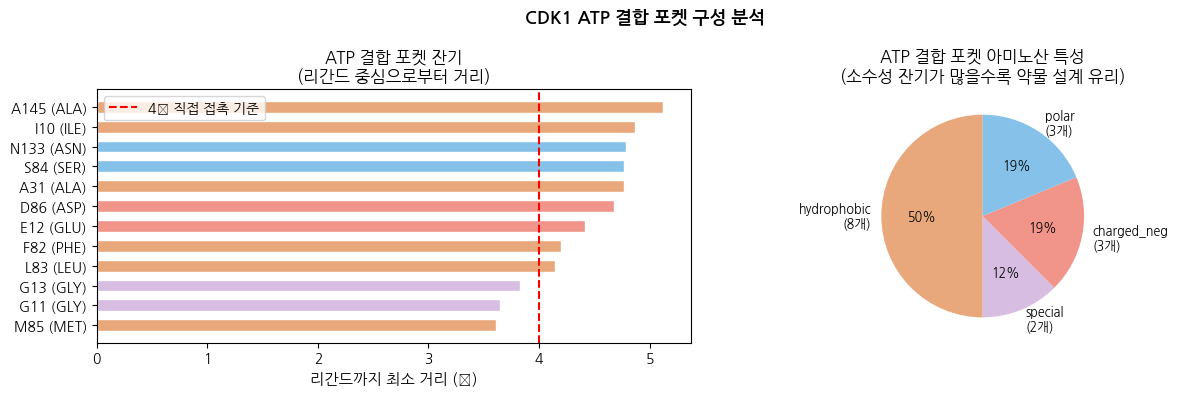

▶ 소수성(hydrophobic) 잔기가 많은 포켓 → 소수성 약물 설계 유리
▶ 실제 CDK 억제제(Palbociclib)도 소수성 코어 + 수소결합 부분으로 구성


In [10]:
# ======================================
# 📊 결합 포켓 잔기 특성 분석
# 어떤 종류의 아미노산이 포켓을 구성하는가?
# ======================================

if len(binding_residues) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # 왼쪽: 결합 거리별 잔기
    df_plot = df_binding.head(12)
    bar_colors = [get_aa_color(aa) for aa in df_plot['aa_1letter']]
    axes[0].barh(
        [f"{r['aa_1letter']}{r['res_num']} ({r['res_name']})" for _, r in df_plot.iterrows()],
        df_plot['min_dist'],
        color=bar_colors, edgecolor='white', height=0.6
    )
    axes[0].axvline(4.0, color='red', linestyle='--', linewidth=1.5,
                   label='4Å 직접 접촉 기준')
    axes[0].set_xlabel('리간드까지 최소 거리 (Å)', fontsize=11)
    axes[0].set_title('ATP 결합 포켓 잔기\n(리간드 중심으로부터 거리)', fontsize=12)
    axes[0].legend(fontsize=10)

    # 오른쪽: 포켓 잔기 특성 파이차트
    pocket_prop_counts = defaultdict(int)
    for _, row in df_binding.iterrows():
        aa = row['aa_1letter']
        for prop, aas in aa_properties.items():
            if aa in aas:
                pocket_prop_counts[prop] += 1
                break

    axes[1].pie(
        pocket_prop_counts.values(),
        labels=[f'{p}\n({v}개)' for p, v in pocket_prop_counts.items()],
        colors=[prop_colors[p] for p in pocket_prop_counts],
        autopct='%1.0f%%',
        startangle=90,
        textprops={'fontsize': 9}
    )
    axes[1].set_title('ATP 결합 포켓 아미노산 특성\n(소수성 잔기가 많을수록 약물 설계 유리)', fontsize=12)

    plt.suptitle('CDK1 ATP 결합 포켓 구성 분석', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('▶ 소수성(hydrophobic) 잔기가 많은 포켓 → 소수성 약물 설계 유리')
    print('▶ 실제 CDK 억제제(Palbociclib)도 소수성 코어 + 수소결합 부분으로 구성')

/tmp/ipykernel_25968/3184786348.py:38: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) NanumGothic.
  plt.tight_layout()
/home/vscode/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


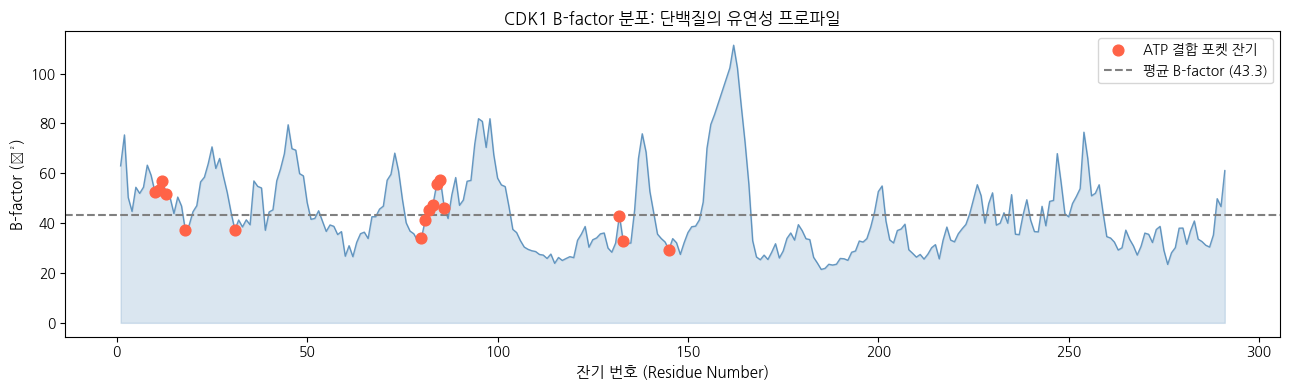

▶ 전체 평균 B-factor: 43.3 Å²
▶ 결합 포켓 평균 B-factor: 45.0 Å²
▶ 결합 포켓이 유연한 편 → 구조 기반 약물 설계 시 고려 필요


In [11]:
# ======================================
# 📊 B-factor 분석: 단백질의 유연한 부위
# B-factor가 높을수록 원자의 움직임이 크다
# → 약물 결합 부위는 보통 B-factor가 낮음 (단단함)
# ======================================

cdk1_ca_full = df_atoms[
    (df_atoms['chain'] == 'A') &
    (df_atoms['record'] == 'ATOM') &
    (df_atoms['atom_name'] == 'CA')
].copy()

fig, ax = plt.subplots(figsize=(13, 4))

# 전체 B-factor 플롯
ax.plot(cdk1_ca_full['res_num'], cdk1_ca_full['b_factor'],
        color='steelblue', linewidth=1, alpha=0.8)
ax.fill_between(cdk1_ca_full['res_num'], cdk1_ca_full['b_factor'],
                alpha=0.2, color='steelblue')

# 결합 포켓 잔기 강조
if len(binding_residues) > 0:
    pocket_res = df_binding['res_num'].values
    pocket_bf  = cdk1_ca_full[cdk1_ca_full['res_num'].isin(pocket_res)]
    ax.scatter(pocket_bf['res_num'], pocket_bf['b_factor'],
               color='tomato', s=60, zorder=5, label='ATP 결합 포켓 잔기')

# 평균 B-factor 기준선
mean_bf = cdk1_ca_full['b_factor'].mean()
ax.axhline(mean_bf, color='gray', linestyle='--', linewidth=1.5,
           label=f'평균 B-factor ({mean_bf:.1f})')

ax.set_xlabel('잔기 번호 (Residue Number)', fontsize=11)
ax.set_ylabel('B-factor (Å²)', fontsize=11)
ax.set_title('CDK1 B-factor 분포: 단백질의 유연성 프로파일', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

pocket_mean_bf = cdk1_ca_full[cdk1_ca_full['res_num'].isin(pocket_res)]['b_factor'].mean()
print(f'▶ 전체 평균 B-factor: {mean_bf:.1f} Å²')
print(f'▶ 결합 포켓 평균 B-factor: {pocket_mean_bf:.1f} Å²')
if pocket_mean_bf < mean_bf:
    print('▶ 결합 포켓이 평균보다 단단함 → 약물 결합에 유리한 구조!')
else:
    print('▶ 결합 포켓이 유연한 편 → 구조 기반 약물 설계 시 고려 필요')

---
## 💊 3-5. CDK 억제제와 구조 기반 약물 설계

### 실제 CDK1/CDK4/CDK6 억제제

| 약물명 | 타겟 | 적응증 | 결합 방식 |
|--------|------|--------|----------|
| Palbociclib | CDK4/6 | 유방암 | ATP 포켓 경쟁적 억제 |
| Ribociclib  | CDK4/6 | 유방암 | ATP 포켓 경쟁적 억제 |
| Abemaciclib | CDK4/6 | 유방암 | ATP 포켓 경쟁적 억제 |
| RO-3306     | CDK1   | 연구용 | ATP 포켓 결합 |

> 💡 간암에서 CDK1이 높다는 우리의 발견 →  
> CDK1 선택적 억제제 개발 또는 기존 CDK 억제제 적용 가능성 제시

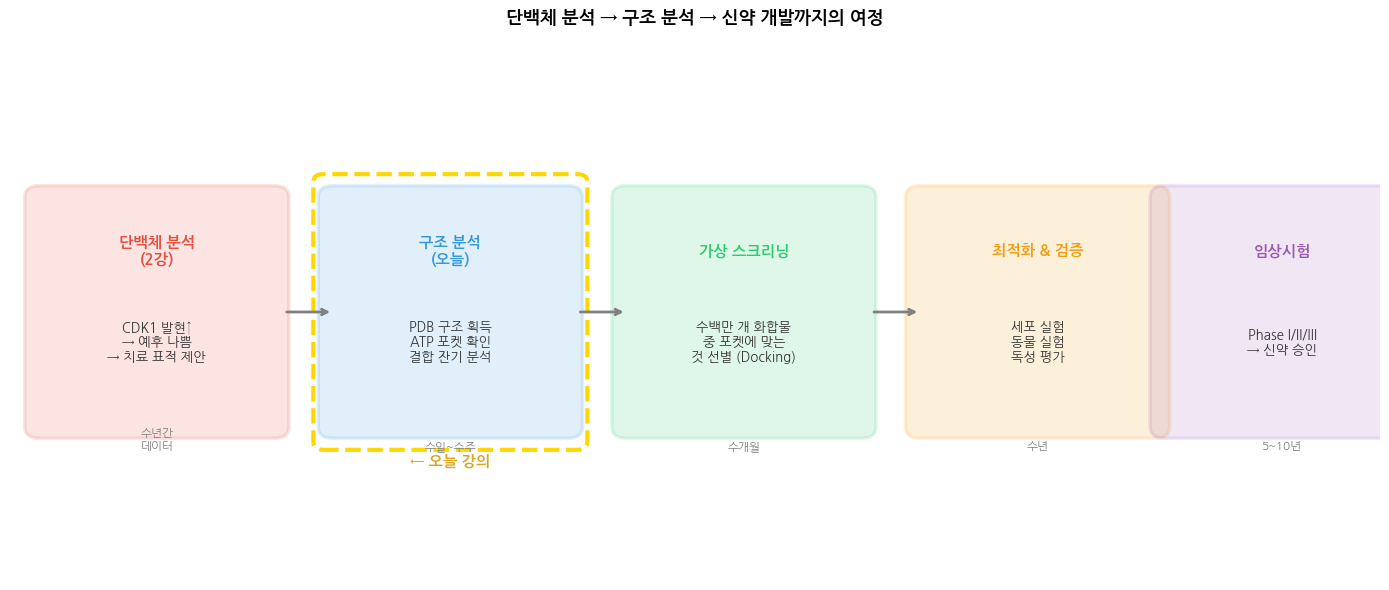

▶ 오늘 배운 구조 분석은 신약 개발 파이프라인의 핵심 단계입니다
▶ 2강의 단백체 데이터 → 3강의 구조 분석이 실제 연구에서 이렇게 연결됩니다


In [12]:
# ======================================
# 💊 구조 기반 약물 설계 흐름 시각화
# ======================================

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')

steps = [
    (1.5, 3.5, '단백체 분석\n(2강)',
     'CDK1 발현↑\n→ 예후 나쁨\n→ 치료 표적 제안',
     '#E74C3C'),
    (4.5, 3.5, '구조 분석\n(오늘)',
     'PDB 구조 획득\nATP 포켓 확인\n결합 잔기 분석',
     '#3498DB'),
    (7.5, 3.5, '가상 스크리닝',
     '수백만 개 화합물\n중 포켓에 맞는\n것 선별 (Docking)',
     '#2ECC71'),
    (10.5, 3.5, '최적화 & 검증',
     '세포 실험\n동물 실험\n독성 평가',
     '#F39C12'),
    (13.0, 3.5, '임상시험',
     'Phase I/II/III\n→ 신약 승인',
     '#9B59B6'),
]

for x, y, title, content, color in steps:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x-1.2, y-1.5), 2.4, 3.0,
        boxstyle='round,pad=0.15',
        facecolor=color, alpha=0.15,
        edgecolor=color, linewidth=2.5
    ))
    ax.text(x, y+0.8, title, ha='center', va='center',
            fontsize=11, fontweight='bold', color=color)
    ax.text(x, y-0.4, content, ha='center', va='center',
            fontsize=9.5, color='#333333')

# 화살표
arrow_xs = [(2.8, 3.3), (5.8, 6.3), (8.8, 9.3), (11.8, 11.8)]
for x1, x2 in arrow_xs:
    ax.annotate('', xy=(x2, 3.5), xytext=(x1, 3.5),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# 오늘 강의 위치 표시
ax.add_patch(mpatches.FancyBboxPatch(
    (3.2, 1.8), 2.6, 3.4,
    boxstyle='round,pad=0.1',
    facecolor='none',
    edgecolor='gold', linewidth=3, linestyle='--'
))
ax.text(4.5, 1.5, '← 오늘 강의', ha='center',
        fontsize=11, color='goldenrod', fontweight='bold')

# 소요 기간
durations = ['수년간\n데이터', '수일~수주', '수개월', '수년', '5~10년']
for (x, _, _, _, _), dur in zip(steps, durations):
    ax.text(x, 1.7, dur, ha='center', fontsize=8.5, color='gray')

ax.set_title('단백체 분석 → 구조 분석 → 신약 개발까지의 여정',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('▶ 오늘 배운 구조 분석은 신약 개발 파이프라인의 핵심 단계입니다')
print('▶ 2강의 단백체 데이터 → 3강의 구조 분석이 실제 연구에서 이렇게 연결됩니다')

---
## ✅ 3강 & 전체 강의 정리

### 오늘 배운 것

| 단계 | 내용 | 핵심 개념 |
|------|------|-----------|
| PDB 접근 | 구조 데이터 다운로드 | PDB ID, RCSB API |
| 파일 파싱 | ATOM/HETATM 레코드 | 좌표, 체인, 잔기 |
| 서열 분석 | 아미노산 조성 | 3→1글자 변환 |
| 3D 시각화 | py3Dmol | Cartoon/Surface/Stick |
| 활성부위 | ATP 포켓 잔기 | 거리 계산 (Å) |
| B-factor | 유연성 분석 | 약물 결합 적합성 |

### 3강의 전체 스토리

```
1강: 질량분석으로 단백질을 어떻게 찾는가?
       ↓
2강: 찾은 단백질로 환자를 이해하고 타겟을 발굴한다
       ↓
3강: 타겟의 3D 구조로 약물 결합 부위를 찾는다
       ↓
    신약 개발로 이어진다
```

### 더 배우고 싶다면
- **AutoDock Vina** — 분자 도킹 시뮬레이션
- **AlphaFold2** — 서열만으로 3D 구조 예측
- **MDAnalysis** — 분자동역학 시뮬레이션 분석
- **RDKit** — 약물 화학 구조 분석

---
*강의에 사용된 CDK1 구조(PDB: 6GU6)는 RCSB PDB의 공개 데이터입니다.*